In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import glob
import os
from matplotlib import cm


In [3]:
def drop_outlier(array,count,bins):
    index = []
    range_ = np.arange(1,count,bins)
    for i in range_[:-1]:
        array_lim = array[i:i+bins]
        sigma = np.std(array_lim)
        mean = np.mean(array_lim)
        th_max,th_min = mean + sigma*2, mean - sigma*2
        idx = np.where((array_lim < th_max) & (array_lim > th_min))
        idx = idx[0] + i
        index.extend(list(idx))
    return np.array(index)

### 從 xlsx 文件中提取信息

Load Dataset CS2_33 ...


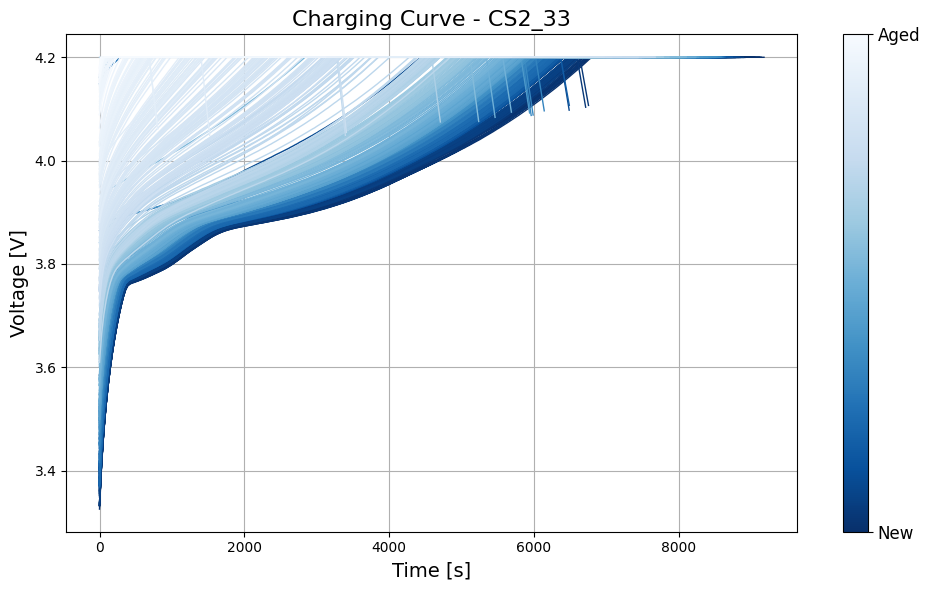

In [6]:
# Battery_list = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']

# dir_path = 'C:/Users/1129/Desktop/CALCE-main/dataset/'
# Battery = {}
# for name in Battery_list:
#     print('Load Dataset ' + name + ' ...')
#     path = [p for p in glob.glob(dir_path + name + '/*.xlsx') if '~$' not in p]
#     dates = []
#     for p in path:
#         df = pd.read_excel(p, sheet_name=1)
#         print('Load ' + str(p) + ' ...')
#         dates.append(df['Date_Time'][0])
#     idx = np.argsort(dates)
#     path_sorted = np.array(path)[idx]
    
#     count = 0
#     discharge_capacities = []
#     health_indicator = []
#     internal_resistance = []
#     CCCT = []
#     CVCT = []
    
#     # 收集所有 cycle 的時間與電壓（僅取 Charging）
#     charge_time_list = []
#     charge_voltage_list = []
    
#     for p in path_sorted:
#         df = pd.read_excel(p, sheet_name=0)
#         cycles = sorted(list(set(df['Cycle_Index'])))

#         for c in cycles:
#             df_lim = df[df['Cycle_Index'] == c]
#             df_c = df_lim[(df_lim['Step_Index'] == 2) | (df_lim['Step_Index'] == 4)]

#             c_v = df_c['Voltage(V)'].values
#             c_t = df_c['Test_Time(s)'].values

#             if len(c_v) > 10:
#                 charge_time_list.append(c_t)
#                 charge_voltage_list.append(c_v)

#             # 畫圖：疊加充電曲線 + 色條代表老化程度
#             from matplotlib import cm

#             num_curves = len(charge_time_list)
#             colors = cm.Blues_r(np.linspace(0, 1, num_curves))  # 新 → 舊

#             plt.figure(figsize=(10, 6))
#             for i in range(num_curves):
#                 plt.plot(charge_time_list[i], charge_voltage_list[i], color=colors[i], linewidth=2)

#             plt.xlabel('Time [s]', fontsize=14)
#             plt.ylabel('Voltage [V]', fontsize=14)
#             plt.xticks(fontsize=12)
#             plt.yticks(fontsize=12)
#             plt.grid(True)

#             # colorbar 顯示新舊 cycle
#             sm = plt.cm.ScalarMappable(cmap=cm.Blues_r)
#             sm.set_array([])
#             cbar = plt.colorbar(sm, ticks=[0, 1])
#             cbar.ax.set_yticklabels(['New', 'Aged'], fontsize=12)

#             plt.title(f'Voltage vs Time - {name}', fontsize=16)
#             plt.tight_layout()
#             plt.show()
            
#             #CC or CV
#             df_cc = df_lim[df_lim['Step_Index'] == 2]
#             df_cv = df_lim[df_lim['Step_Index'] == 4]
#             CCCT.append(np.max(df_cc['Test_Time(s)'])-np.min(df_cc['Test_Time(s)']))
#             CVCT.append(np.max(df_cv['Test_Time(s)'])-np.min(df_cv['Test_Time(s)']))

#             #Discharging
#             df_d = df_lim[df_lim['Step_Index'] == 7]
#             d_v = df_d['Voltage(V)']
#             d_c = df_d['Current(A)']
#             d_t = df_d['Test_Time(s)']
#             d_im = df_d['Internal_Resistance(Ohm)']

#             if(len(list(d_c)) != 0):
#                 time_diff = np.diff(list(d_t))
#                 d_c = np.array(list(d_c))[1:]
#                 discharge_capacity = time_diff*d_c/3600 # Q = A*h
#                 discharge_capacity = [np.sum(discharge_capacity[:n]) for n in range(discharge_capacity.shape[0])]
#                 discharge_capacities.append(-1*discharge_capacity[-1])

#                 dec = np.abs(np.array(d_v) - 3.8)[1:]
#                 start = np.array(discharge_capacity)[np.argmin(dec)]
#                 dec = np.abs(np.array(d_v) - 3.4)[1:]
#                 end = np.array(discharge_capacity)[np.argmin(dec)]
#                 health_indicator.append(-1 * (end - start))

#                 internal_resistance.append(np.mean(np.array(d_im)))
#                 count += 1

#     discharge_capacities = np.array(discharge_capacities)
#     health_indicator = np.array(health_indicator)
#     internal_resistance = np.array(internal_resistance)
#     CCCT = np.array(CCCT)
#     CVCT = np.array(CVCT)
    
#     idx = drop_outlier(discharge_capacities, count, 40)
#     idx = idx.astype(int)  # 加這行讓它變成整數索引
#     df_result = pd.DataFrame({'cycle':np.linspace(1,idx.shape[0],idx.shape[0]),
#                               'capacity':discharge_capacities[idx],
#                               'SoH':health_indicator[idx],
#                               'resistance':internal_resistance[idx],
#                               'CCCT':CCCT[idx],s
#                               'CVCT':CVCT[idx]})
#     Battery[name] = df_result
# Battery_list = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
Battery_list = ['CS2_33']
dir_path = 'C:/Users/王奕傑/Desktop/CALCE-main/dataset/'
Battery = {}

for name in Battery_list:
    print('Load Dataset ' + name + ' ...')
    path = [p for p in glob.glob(dir_path + name + '/*.xlsx') if '~$' not in p]
    dates = []
    for p in path:
        df = pd.read_excel(p, sheet_name=1)
        dates.append(df['Date_Time'][0])
    idx = np.argsort(dates)
    path_sorted = np.array(path)[idx]

    # 新增這兩個 list：用來儲存所有充電曲線
    charge_time_list = []
    charge_voltage_list = []

    count = 0
    discharge_capacities = []
    health_indicator = []
    internal_resistance = []
    CCCT = []
    CVCT = []

    for p in path_sorted:
        df = pd.read_excel(p, sheet_name=1)
        cycles = list(set(df['Cycle_Index']))
        for c in cycles:
            df_lim = df[df['Cycle_Index'] == c]
            # Charging
            df_c = df_lim[(df_lim['Step_Index'] == 2) | (df_lim['Step_Index'] == 4)]
            c_v = df_c['Voltage(V)'].values
            c_t = df_c['Test_Time(s)'].values
            
            # 防止時間軸疊加
            c_t = c_t - c_t[0]  # ✅ 重設時間軸起點為 0
            
            if len(c_v) > 10:
                charge_time_list.append(c_t)
                charge_voltage_list.append(c_v)

            # CC or CV
            df_cc = df_lim[df_lim['Step_Index'] == 2]
            df_cv = df_lim[df_lim['Step_Index'] == 4]
            if not df_cc.empty and not df_cv.empty:
                CCCT.append(np.max(df_cc['Test_Time(s)']) - np.min(df_cc['Test_Time(s)']))
                CVCT.append(np.max(df_cv['Test_Time(s)']) - np.min(df_cv['Test_Time(s)']))

            # Discharging
            df_d = df_lim[df_lim['Step_Index'] == 7]
            d_v = df_d['Voltage(V)']
            d_c = df_d['Current(A)']
            d_t = df_d['Test_Time(s)']
            d_im = df_d['Internal_Resistance(Ohm)']

            if len(list(d_c)) != 0:
                time_diff = np.diff(list(d_t))
                d_c = np.array(list(d_c))[1:]
                discharge_capacity = time_diff * d_c / 3600
                discharge_capacity = [np.sum(discharge_capacity[:n]) for n in range(len(discharge_capacity))]
                discharge_capacities.append(-1 * discharge_capacity[-1])

                dec = np.abs(np.array(d_v) - 3.8)[1:]
                start = np.array(discharge_capacity)[np.argmin(dec)]
                dec = np.abs(np.array(d_v) - 3.4)[1:]
                end = np.array(discharge_capacity)[np.argmin(dec)]
                health_indicator.append(-1 * (end - start))

                internal_resistance.append(np.mean(np.array(d_im)))
                count += 1

    # ✅ 畫圖：全部充電曲線 疊加一張圖
    from matplotlib import cm
    num_curves = len(charge_time_list)
    colors = cm.Blues_r(np.linspace(0, 1, num_curves))  # 新到舊

    # ✅ 修正後的 Colorbar 區塊
    fig, ax = plt.subplots(figsize=(10, 6)) # 明確建立 fig 與 ax
    for i in range(num_curves):
        ax.plot(charge_time_list[i], charge_voltage_list[i], color=colors[i], linewidth=1)

    ax.set_xlabel('Time [s]', fontsize=14)
    ax.set_ylabel('Voltage [V]', fontsize=14)
    ax.set_title(f'Charging Curve - {name}', fontsize=16)
    ax.grid(True)

    # 建立一個可對應的顏色對象
    sm = plt.cm.ScalarMappable(cmap=cm.Blues_r)
    sm.set_array([])
    
    # 指定 ax=ax，解決 "Unable to determine Axes" 報錯
    cbar = fig.colorbar(sm, ax=ax, ticks=[0, 1]) 
    cbar.ax.set_yticklabels(['New', 'Aged'], fontsize=12)

    plt.tight_layout()
    plt.show()

    # 其他資料處理照舊
    discharge_capacities = np.array(discharge_capacities)
    health_indicator = np.array(health_indicator)
    internal_resistance = np.array(internal_resistance)
    CCCT = np.array(CCCT)
    CVCT = np.array(CVCT)

    min_len = min(len(discharge_capacities), len(health_indicator), len(internal_resistance), len(CCCT), len(CVCT))
    idx = drop_outlier(discharge_capacities[:min_len], count, 40).astype(int)

    df_result = pd.DataFrame({
        'cycle': np.linspace(1, idx.shape[0], idx.shape[0]),
        'capacity': discharge_capacities[:min_len][idx],
        'SoH': health_indicator[:min_len][idx],
        'resistance': internal_resistance[:min_len][idx],
        'CCCT': CCCT[:min_len][idx],
        'CVCT': CVCT[:min_len][idx]
    })

    # 將結果存入 Battery 字典
    Battery[name] = df_result
    
    # # CX2_8_1 的資料夾路徑
    # temp_path = 'C:/Users/1129/Desktop/CALCE-main/dataset/CX2_8_1'
    # file_paths = [p for p in glob.glob(os.path.join(temp_path, '*.xlsx')) if '~$' not in p]

    # plt.figure(figsize=(10, 6))

    # for p in file_paths:
    #     df = pd.read_excel(p, sheet_name=0)

    #     # 確保資料正確
    #     df = df.dropna(subset=['Test_Time(s)', 'Temperature(C)'])
    #     df['Test_Time(s)'] = pd.to_numeric(df['Test_Time(s)'], errors='coerce')
    #     df['Temperature(C)'] = pd.to_numeric(df['Temperature(C)'], errors='coerce')

    #     # 畫出每一組的溫度曲線
    #     plt.plot(df['Test_Time(s)'], df['Temperature(C)'], alpha=0.6)

    # plt.xlabel('Time [s]')
    # plt.ylabel('Temperature [°C]')
    # plt.title('Temperature vs Time for CX2_8_1')
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()


### 如果上面的讀取資料集失敗，可以透過下面的方式載入已提取出來的數據

In [ ]:
# Battery_list = ['CS2_35', 'CS2_36', 'CS2_37', 'CS2_38']
# Battery = np.load('dataset/CALCE.npy', allow_pickle=True)
# Battery = Battery.item()

### 放電容量 v.s. 放電週期

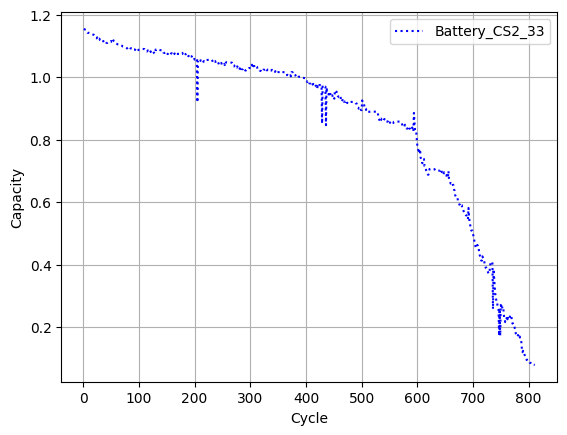

In [8]:
# # 四個圖時
# #Rated_Capacity = 1.1
# fig, ax = plt.subplots(1, figsize=(12, 8))
# color_list = ['b:', 'g--', 'r-.', 'c:']
# # color_list = ['b:', 'g--', 'r-.', 'c:']
# for name,color in zip(Battery_list, color_list):
#     battery = Battery[name]
#     ax.plot(battery['cycle'], battery['capacity'], color, label='Battery_'+name)
# #plt.plot([-1,1000],[Rated_Capacity*0.7, Rated_Capacity*0.7], c='black', lw=1, ls='--')  # 临界点直线
# ax.set(xlabel='Discharge cycles', ylabel='Capacity (Ah)', title='Capacity degradation at ambient temperature of 1°C')
# plt.legend()
# 一個圖時
color_list = ['b:']  # 只保留一個顏色
Battery_list = ['CS2_33']

for name, color in zip(Battery_list, color_list):
    battery = Battery[name]
    plt.plot(battery['cycle'], battery['capacity'], color, label='Battery_' + name)

plt.xlabel('Cycle')
plt.ylabel('Capacity')
plt.legend()
plt.grid(True)
plt.show()

### 放電容量和內阻變化

Text(0, 0.5, 'State of Health')

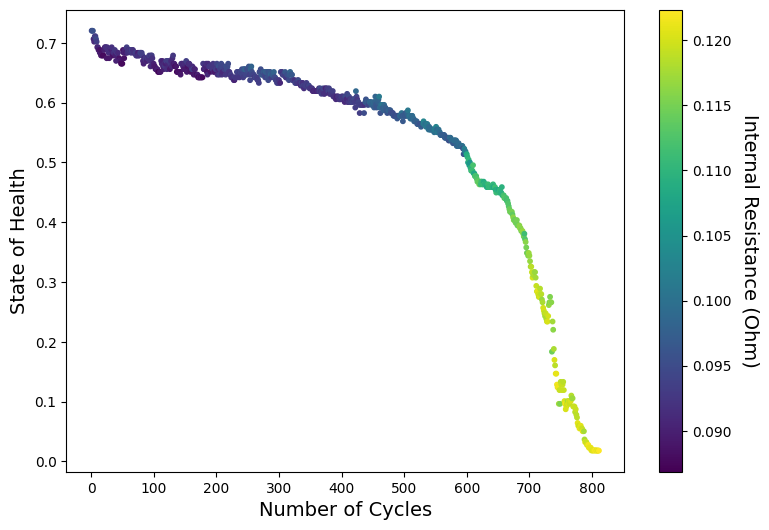

In [9]:
battery = Battery['CS2_33']
plt.figure(figsize=(9,6))
plt.scatter(battery['cycle'], battery['SoH'], c=battery['resistance'], s=10)
cbar = plt.colorbar()
cbar.set_label('Internal Resistance (Ohm)', fontsize=14, rotation=-90, labelpad=20)
plt.xlabel('Number of Cycles', fontsize=14)
plt.ylabel('State of Health', fontsize=14)

### 各項指標vs充放電週期

In [ ]:
battery = Battery['CS2_33']
plt.figure(figsize=(12,9))
names = ['capacity', 'resistance', 'CCCT', 'CVCT']
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.scatter(battery['cycle'], battery[names[i]], s=10)
    plt.xlabel('Number of Cycles', fontsize=14)
    plt.ylabel(names[i], fontsize=14)

KeyError: 'CS2_33'

# 溫度隨時間(s)的變化

Load Dataset CS2_8_1 ...


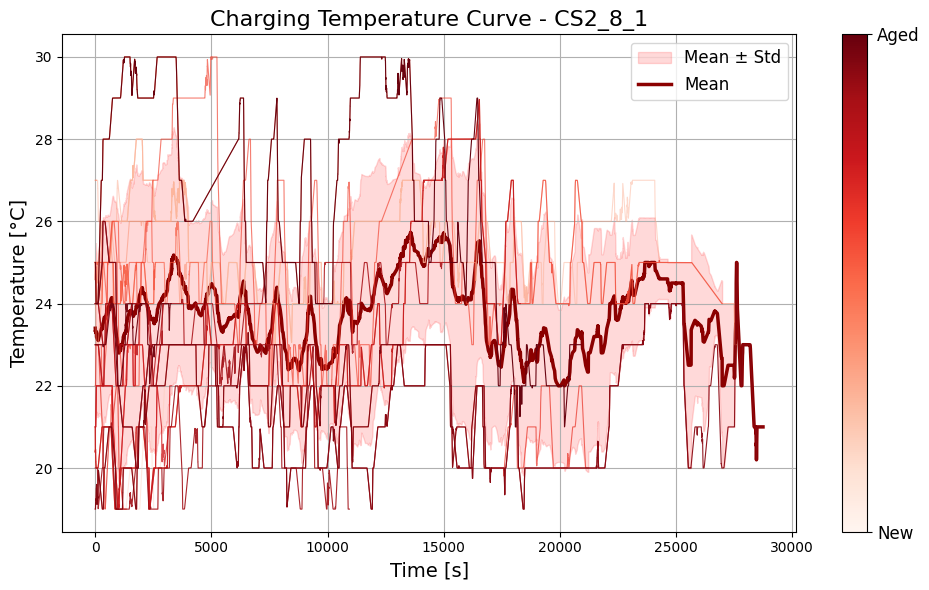

In [ ]:
# # 🔋 額外畫一張 CS2_35 第 1 cycle 的充電過程 Voltage vs Time
# df = pd.read_excel(r"C:\Users\1129\Desktop\CALCE-main\dataset\CS2_35\CS2_35_1_10_11.xlsx", sheet_name=0)
# df_lim = df[df['Cycle_Index'] == 1]

# df_c = df_lim[(df_lim['Step_Index'] == 2) | (df_lim['Step_Index'] == 4)]
# c_v = df_c['Voltage(V)']
# c_t = df_c['Test_Time(s)']

# plt.figure(figsize=(10, 6))
# plt.plot(c_v, c_t, color='green', label='Charging')
# plt.xlabel('Voltage (V)', fontsize=14)
# plt.ylabel('Time (s)', fontsize=14)
# plt.title('Voltage vs Time - Charging - CS2_35 Cycle 1', fontsize=16)
# plt.grid(True)
# plt.legend()
# plt.show()

# # 資料夾位置
# temp_path = 'C:/Users/1129/Desktop/CALCE-main/dataset/CS2_8_1'

# # 找出所有 .xlsx 檔案（排除暫存檔）
# file_paths = [p for p in glob.glob(os.path.join(temp_path, '*.xlsx')) if '~$' not in p]

# # 畫圖統一時長
# for p in file_paths:
#     df = pd.read_excel(p)

#     # 移除空值並轉數字
#     df = df.dropna(subset=['Time', 'Temperature'])
#     df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
#     df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')

#     # 限制時間範圍在 0~8000 秒
#     df = df[(df['Time'] >= 0) & (df['Time'] <= 10000)]

#     # 畫圖
#     plt.plot(df['Time'], df['Temperature'], alpha=0.6, label=os.path.basename(p))

# plt.xlabel('Time [s]', fontsize=14)
# plt.ylabel('Temperature [°C]', fontsize=14)
# plt.title('Temperature vs Time (limited to 0~10000s)', fontsize=16)
# plt.grid(True)
# plt.legend(fontsize=6)
# plt.tight_layout()
# plt.show()

# # 畫圖(未統一時長)
# plt.figure(figsize=(12, 6))

# for p in file_paths:
#     # 讀取檔案（sheet 1）
#     df = pd.read_excel(p, sheet_name=0)
#     # 檢查欄位名稱用
#     # print(df.columns)
#     # 移除空值並轉數字
#     df = df.dropna(subset=['Time', 'Temperature'])
#     df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
#     df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')
#     # 每筆資料畫一條線
#     plt.plot(df['Time'], df['Temperature'], alpha=0.6, label=os.path.basename(p))

#     # 如果數據長度過短就跳過（避免異常）
#     if len(df) < 10:
#         continue
    
# plt.xlabel('Time', fontsize=14)
# plt.ylabel('Temperature', fontsize=14)
# plt.title('Temperature vs Time (CS2_8_1)', fontsize=16)
# plt.grid(True)
# plt.tight_layout()

# # 如果想要顯示圖例（可選）
# # plt.legend(fontsize=8, loc='upper right')

# plt.show()

# import matplotlib.cm as cm
# from glob import glob
# import os

# file_paths = [p for p in glob(os.path.join(temp_path, '*.xlsx')) if '~$' not in p]
# cmap = cm.get_cmap('Reds', len(file_paths))  # 紅色漸層，代表時間老化
# plt.figure(figsize=(10, 5))

# all_interp_temp = []
# common_time = np.linspace(0, 10000, 2000)

# for idx, path in enumerate(file_paths):
#     try:
#         df = pd.read_excel(path)

#         # 確保需要的欄位存在
#         if 'Time' not in df.columns or 'Temperature' not in df.columns:
#             print(f" 欄位缺失，跳過: {os.path.basename(path)}")
#             continue

#         # 清理與轉型
#         df = df.dropna(subset=['Time', 'Temperature'])
#         df['Time'] = pd.to_numeric(df['Time'], errors='coerce')
#         df['Temperature'] = pd.to_numeric(df['Temperature'], errors='coerce')
#         df = df.dropna(subset=['Time', 'Temperature'])

#         # 限制在 0~10000 秒
#         df = df[(df['Time'] >= 0) & (df['Time'] <= 10000)]

#         if df.empty:
#             print(f" 清理後無資料: {os.path.basename(path)}")
#             continue

#         # 補內插
#         interp_temp = np.interp(common_time, df['Time'], df['Temperature'])
#         all_interp_temp.append(interp_temp)

#         # 畫線（透明度由時間疊加）
#         plt.plot(common_time, interp_temp, color=cmap(idx), alpha=0.2)

#     except Exception as e:
#         print(f" 讀取失敗：{path}，錯誤：{e}")

# # 畫中位數趨勢線
# if all_interp_temp:
#     all_interp_temp = np.array(all_interp_temp)
#     median_temp = np.median(all_interp_temp, axis=0)
#     plt.plot(common_time, median_temp, color='black', linewidth=2, label='Median')

#     # 顯示設定
#     plt.xlabel('Time [s]', fontsize=14)
#     plt.ylabel('Temperature [°C]', fontsize=14)
#     plt.title('Temperature Evolution Over Time (New → Aged)', fontsize=16)
#     plt.xlim(0, 10000)
#     plt.grid(True)
#     plt.legend()
#     plt.tight_layout()
#     plt.show()

#     print(f"✅ 總共畫了 {len(all_interp_temp)} 條線")
# else:
#     print(" 沒有任何有效資料可以繪圖")

# 🔧 平滑函數：簡單滑動平均

# 未美化的圖
# def smooth(y, box_pts=5):
#     box = np.ones(box_pts)/box_pts
#     y_smooth = np.convolve(y, box, mode='same')
#     return y_smooth

# Battery_list = ['CS2_8_1']
# dir_path = 'C:/Users/1129/Desktop/CALCE-main/dataset/'
# Battery = {}

# for name in Battery_list:
#     print('Load Dataset ' + name + ' ...')
#     path = [p for p in glob.glob(dir_path + name + '/*.xlsx') if '~$' not in p]
#     dates = []
#     for p in path:
#         df = pd.read_excel(p, sheet_name=0)
#         dates.append(df['Time'][0])

#     idx = np.argsort(dates)
#     path_sorted = np.array(path)[idx]

#     temp_time_list = []
#     temp_value_list = []

#     for p in path_sorted:
#         df = pd.read_excel(p, sheet_name=0)
#         cycles = list(set(df['Pgm cycle']))
#         for c in cycles:
#             df_lim = df[df['Pgm cycle'] == c]

#             # 所有充電資料點（包含 Step 2, 4）
#             df_c = df_lim[(df_lim['Pgm step'] == 2) | (df_lim['Pgm step'] == 4)]
#             c_t = df_c['Time'].values
#             c_temp = df_c['Temperature'].values

#             if len(c_t) > 0:
#                 c_t = c_t - c_t[0]  # 重設時間起點
#                 mask = c_t <= 10000
#                 if np.sum(mask) > 10:
#                     temp_time_list.append(c_t[mask])
#                     # ✅ 溫度平滑處理
#                     smooth_temp = smooth(c_temp[mask], box_pts=5)
#                     temp_value_list.append(smooth_temp)

#     # ✅ 畫圖
#     num_curves = len(temp_time_list)
#     colors = cm.Oranges(np.linspace(0, 1, num_curves))

#     plt.figure(figsize=(10, 6))
#     for i in range(num_curves):
#         plt.plot(temp_time_list[i], temp_value_list[i], color=colors[i], linewidth=1)

#     plt.xlabel('Time [s]', fontsize=14)
#     plt.ylabel('Temperature [°C]', fontsize=14)
#     plt.title(f'Charging Temperature Curve - {name}', fontsize=16)
#     plt.grid(True)

#     sm = plt.cm.ScalarMappable(cmap=cm.Oranges)
#     sm.set_array([])
#     cbar = plt.colorbar(sm, ticks=[0, 1])
#     cbar.ax.set_yticklabels(['New', 'Aged'], fontsize=12)

#     plt.tight_layout()
#     plt.show()
# 美化的圖
# from scipy.interpolate import interp1d

# Battery_list = ['CS2_8_1']
# dir_path = 'C:/Users/1129/Desktop/CALCE-main/dataset/'

# for name in Battery_list:
#     print('Load Dataset ' + name + ' ...')
#     path = [p for p in glob.glob(dir_path + name + '/*.xlsx') if '~$' not in p]
#     dates = [pd.read_excel(p).iloc[0]['Time'] for p in path]
#     path_sorted = np.array(path)[np.argsort(dates)]

#     temp_time_list = []
#     temp_value_list = []
#     max_time = 0

#     # 🔍 掃資料並找最大時間
#     for p in path_sorted:
#         df = pd.read_excel(p)
#         for c in set(df['Pgm cycle']):
#             df_c = df[(df['Pgm cycle'] == c) & ((df['Pgm step'] == 2) | (df['Pgm step'] == 4))]
#             t = df_c['Time'].values
#             if len(t) > 10:
#                 t = t - t[0]
#                 max_time = max(max_time, t.max())
#                 temp_time_list.append(t)
#                 temp_value_list.append(df_c['Temperature'].values)

#     # ✅ 建時間網格並插值
#     temp_grid = np.linspace(0, max_time, int(max_time) + 1)
#     temp_matrix = []

#     for t, temp in zip(temp_time_list, temp_value_list):
#         try:
#             f_interp = interp1d(t, temp, kind='linear', bounds_error=False, fill_value=np.nan)
#             temp_interp = f_interp(temp_grid)
#             temp_matrix.append(temp_interp)
#         except Exception as e:
#             print(f"Interpolation error: {e}")

#     temp_matrix = np.array(temp_matrix)
#     temp_mean = np.nanmean(temp_matrix, axis=0)
#     temp_std = np.nanstd(temp_matrix, axis=0)

#     # 🎨 顏色設定
#     num_curves = len(temp_matrix)
#     colors = cm.Reds(np.linspace(0, 1, num_curves))

#     # ✅ 畫圖
#     plt.figure(figsize=(10, 6))
#     plt.fill_between(temp_grid, temp_mean - temp_std, temp_mean + temp_std,
#                      color='red', alpha=0.2, label='Mean ± Std')
#     plt.plot(temp_grid, temp_mean, color='red', linewidth=2.5, label='Mean')

#     for i in range(num_curves):
#         plt.plot(temp_grid, temp_matrix[i], color=colors[i], linewidth=0.8, alpha=0.5)

#     plt.xlabel('Time [s]', fontsize=14)
#     plt.ylabel('Temperature [°C]', fontsize=14)
#     plt.title(f'Charging Temperature Curve - {name}', fontsize=16)
#     plt.grid(True)
#     plt.legend(fontsize=12)

#     sm = plt.cm.ScalarMappable(cmap=cm.Reds)
#     sm.set_array([])
#     cbar = plt.colorbar(sm, ticks=[0, 1])
#     cbar.ax.set_yticklabels(['New', 'Aged'], fontsize=12)

#     plt.tight_layout()
#     plt.show()
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.interpolate import interp1d

Battery_list = ['CS2_8_1']
dir_path = 'C:/Users/1129/Desktop/CALCE-main/dataset/'

for name in Battery_list:
    print('Load Dataset ' + name + ' ...')
    path = [p for p in glob.glob(dir_path + name + '/*.xlsx') if '~$' not in p]
    dates = [pd.read_excel(p).iloc[0]['Time'] for p in path]
    path_sorted = np.array(path)[np.argsort(dates)]

    temp_time_list = []
    temp_value_list = []
    max_time = 0

    for p in path_sorted:
        df = pd.read_excel(p)
        for c in set(df['Pgm cycle']):
            df_c = df[(df['Pgm cycle'] == c) & ((df['Pgm step'] == 2) | (df['Pgm step'] == 4))]
            t = df_c['Time'].values
            if len(t) > 10:
                t = t - t[0]
                max_time = max(max_time, t.max())
                temp_time_list.append(t)
                temp_value_list.append(df_c['Temperature'].values)

    temp_grid = np.linspace(0, max_time, int(max_time) + 1)
    temp_matrix = []

    for t, temp in zip(temp_time_list, temp_value_list):
        try:
            f_interp = interp1d(t, temp, kind='linear', bounds_error=False, fill_value=np.nan)
            temp_interp = f_interp(temp_grid)
            temp_matrix.append(temp_interp)
        except Exception as e:
            print(f"Interpolation error: {e}")

    temp_matrix = np.array(temp_matrix)
    
    # 🌀 曲線平滑 (rolling average)
    temp_matrix_smooth = pd.DataFrame(temp_matrix).rolling(window=20, axis=1, min_periods=1).mean().values
    
    temp_mean = np.nanmean(temp_matrix_smooth, axis=0)
    temp_std = np.nanstd(temp_matrix_smooth, axis=0)

    # 🎨 顏色從新到舊（由亮轉深）
    num_curves = len(temp_matrix_smooth)
    colors = cm.Reds(np.linspace(0.2, 1, num_curves))  # 避免太亮白，從 0.2 開始

    plt.figure(figsize=(10, 6))
    plt.fill_between(temp_grid, temp_mean - temp_std, temp_mean + temp_std,
                     color='red', alpha=0.15, label='Mean ± Std')
    plt.plot(temp_grid, temp_mean, color='darkred', linewidth=2.5, label='Mean')

    # 🔁 曲線 + 透明度
    for i in range(num_curves):
        plt.plot(temp_grid, temp_matrix_smooth[i], color=colors[i], linewidth=0.8, alpha=0.4 + 0.6 * (i / num_curves))

    plt.xlabel('Time [s]', fontsize=14)
    plt.ylabel('Temperature [°C]', fontsize=14)
    plt.title(f'Charging Temperature Curve - {name}', fontsize=16)
    plt.grid(True)
    plt.legend(fontsize=12)

    # 📊 色條（由新到舊）
    sm = plt.cm.ScalarMappable(cmap=cm.Reds)
    sm.set_array([])
    cbar = plt.colorbar(sm, ticks=[0, 1])
    cbar.ax.set_yticklabels(['New', 'Aged'], fontsize=12)

    plt.tight_layout()
    plt.show()
